### Entendimento do Negócio

A SOMPO é uma seguradora que atua no setor agrícola. Sinistros não planejados em equipamentos (tratores, colheitadeiras, pulverizadores) impactam diretamente:
- A margem de lucro da seguradora (aumento de indenizações)
- O custo da apólice para o produtor rural

Objetivo do modelo: Calcular um Score de Risco (0 a 1) para cada equipamento/operação, onde:

score ≈ 0.1 → Sem risco de sinistro

score ≈ 0.8 → Alto risco de sinistro

Tipo de modelo: Regressão Linear Supervisionada

### Entendimento dos Dados

- Variáveis Operacionais: tipo de equipamento, telemetria, experiência do operador
- Variáveis Ambientais/Geográficas: proximidade hídrica, topografia, clima
- Variáveis de Segurança: densidade de roubos, distância de rodovias

### Preparação dos Dados

Etapas realizadas neste notebook:
1. Simulação da base de dados
2. Limpeza e tratamento de valores nulos
3. Encoding de variáveis categóricas
4. Análise Exploratória (EDA)
5. Insights iniciais sobre variáveis de maior influência

### Modelagem (próxima fase)

Treinamento do modelo de Regressão Linear com divisão 80/20 (treino/teste), encapsulado em API REST.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score


Não existe dataset público que combine todas as variáveis definidas (telemetria agrícola + clima + segurança + perfil do equipamento) de forma integrada. A simulação garante coerência com o domínio do problema e permite validar a pipeline antes da integração com dados reais da SOMPO.

In [ ]:
import pandas as pd
import numpy as np

# quantidade de linhas
N = 1000

# geração dos dados
idade = np.random.randint(1, 15, size=N)

horas_uso = np.random.randint(100, 10000, size=N)

tipo = np.random.choice(
    ['Trator', 'Colheitadeira', 'Pulverizador'],
    size=N
)

temperatura = np.random.normal(30, 5, size=N)

# precipitação (mm)
precipitacao = np.random.normal(50, 20, size=N)
precipitacao = np.clip(precipitacao, 0, None)

# proximidade hídrica (metros)
proximidade_hidrica = np.random.uniform(0, 5000, size=N)

# declividade do terreno (graus)
declividade_terreno = np.random.uniform(0, 45, size=N)

# umidade do solo (%)
umidade_solo = np.random.uniform(0, 100, size=N)

# regra de risco
# Cada fator contribui parcialmente para o risco
risco_sinistro = (
    (proximidade_hidrica < 500).astype(float) * 0.20 +
    (declividade_terreno > 25).astype(float) * 0.20 +
    (precipitacao > 70).astype(float) * 0.15 +
    (temperatura > 25).astype(float) * 0.15 +
    (umidade_solo > 50).astype(float) * 0.15 +
    (horas_uso > 5000).astype(float) * 0.10 +
    (idade > 5).astype(float) * 0.05
)





# dataframe
df = pd.DataFrame({
    'idade_maquina': idade,
    'horas_uso': horas_uso,
    'tipo_equipamento': tipo,
    'temperatura': temperatura,
    'precipitacao': precipitacao,
    'proximidade_hidrica': proximidade_hidrica,
    'declividade_terreno': declividade_terreno,
    'umidade_solo': umidade_solo,
    'risco_sinistro': risco_sinistro
})

# visualizar
print(df.head())

# salvar
df.to_csv('dataset.csv', index=False)


   idade_maquina  horas_uso tipo_equipamento  temperatura  precipitacao  \
0              7       1604     Pulverizador    30.651497     57.836953   
1              7       7587    Colheitadeira    32.734259     50.749709   
2              9       7340     Pulverizador    30.006117     65.979087   
3              8        458    Colheitadeira    27.501643     44.026923   
4              6       2534     Pulverizador    28.060330     61.794472   

   proximidade_hidrica  declividade_terreno  umidade_solo  risco_sinistro  
0            43.386651            33.643104     63.483425            0.75  
1          3108.884041            14.529590     23.206898            0.30  
2          3851.694451             7.971695     18.674353            0.30  
3           363.339633             9.869653      8.506434            0.40  
4          4342.375796            13.304345     55.251041            0.35  


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   idade_maquina        1000 non-null   int64  
 1   horas_uso            1000 non-null   int64  
 2   tipo_equipamento     1000 non-null   object 
 3   temperatura          1000 non-null   float64
 4   precipitacao         1000 non-null   float64
 5   proximidade_hidrica  1000 non-null   float64
 6   declividade_terreno  1000 non-null   float64
 7   umidade_solo         1000 non-null   float64
 8   risco_sinistro       1000 non-null   float64
dtypes: float64(6), int64(2), object(1)
memory usage: 70.4+ KB


In [ ]:
df.describe()

,idade_maquina,horas_uso,temperatura,precipitacao,proximidade_hidrica,declividade_terreno,umidade_solo,risco_sinistro
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,7.502000,5044.724000,29.974737,50.524689,2465.329044,22.226694,50.741093,0.417100
std,4.100098,2893.080266,5.045937,20.535276,1435.042366,12.985513,28.750083,0.170841
min,1.000000,102.000000,10.975881,0.000000,0.107182,0.048659,0.080433,0.000000
25%,4.000000,2528.250000,26.588366,36.125850,1219.498119,11.011122,25.260401,0.300000
50%,7.500000,4959.500000,29.716080,50.323381,2478.798336,22.047008,51.464632,0.400000
75%,11.000000,7606.250000,33.502018,64.457818,3723.230472,33.645331,75.559802,0.550000
max,14.000000,9964.000000,47.511681,107.583700,4994.291454,44.973325,99.668637,1.000000


In [ ]:
df.isnull().sum()

,0
idade_maquina,0
horas_uso,0
tipo_equipamento,0
temperatura,0
precipitacao,0
proximidade_hidrica,0
declividade_terreno,0
umidade_solo,0
risco_sinistro,0


In [ ]:
df = pd.get_dummies(df, columns=['tipo_equipamento'])
X = df.drop('risco_sinistro', axis=1)
y = df['risco_sinistro']

In [ ]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [ ]:
X.train, X.test, y.train, y.test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
print(X.train.shape)
print(X.test.shape)
print(y.train.shape)
print(y.test.shape)

(800, 10)
(200, 10)
(800,)
(200,)


/tmp/ipykernel_2919/6568504.py:1: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  X.train, X.test, y.train, y.test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)


In [ ]:
modelo = LinearRegression()
modelo.fit(X.train, y.train)

LinearRegression()

In [ ]:
y.pred = modelo.predict(X.test)

In [ ]:
mse = mean_squared_error(y.test, y.pred)
r2 = r2_score(y.test, y.pred)

print("MSE:", mse)
print("R²:", r2)

MSE: 0.010227134161423861
R²: 0.6595487536742093


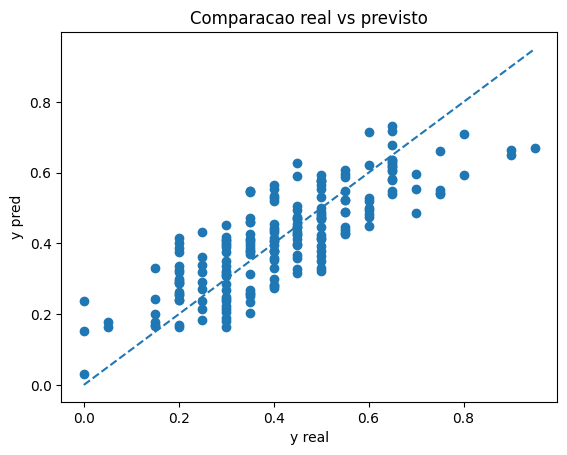

In [ ]:
plt.scatter(y.test, y.pred)
plt.plot([y.test.min(), y.test.max()],
         [y.test.min(), y.test.max()],
         linestyle='--')
plt.xlabel('y real')
plt.ylabel('y pred')
plt.title('Comparacao real vs previsto')
plt.show()

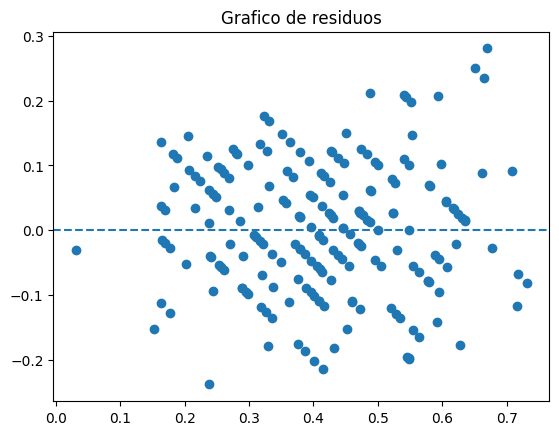

In [ ]:
residuos = y.test - y.pred

plt.scatter(y.pred, residuos)
plt.axhline(0, linestyle='--')
plt.title('Grafico de residuos')
plt.show()

As variáveis que parecem mais influenciar o risco de sinistro seriam a "Proximidade hídrica" que mostra o quão perto da água a maquina está que é um dos maiores perigos para a perda do equipamento, por isso é tão relevante para calcular o risco. A segunda seria a "declividade do terreno", imaginemos que estamos dirigindo sem freio e o carro não consegue subir uma determinada ladeira, esse seria um dos maiores perigos para o carro e se aplica nas máquinas agricolas também. Após essas vem as variaveis que nos mostram informações relacionadas ao estado do ar, ou seja clima, umidade e etc. E por ultimo o tempo de uso e idade da máquina, podemos perceber que as váriaveis tem pesos diferentes quando estamos calculando o risco de sinistro porem todas são importantes.